In [2]:
%reload_ext autoreload
%autoreload 2

from variables import filenames, features, target
from load_dataset import load
from pre_processing import apply, ReplaceInfWithNan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = load(filenames)
df = apply(df)
df.head()

Quantidade de duplicatas antes de remover:  308381


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [4]:
df = df[df['Label'].isin(['BENIGN','DoS slowloris', 'DoS Slowhttptest', 'DoS Hulk', 'DoS GoldenEye'])]
df['Label'].value_counts()

Label
BENIGN              2096484
DoS Hulk             172849
DoS GoldenEye         10286
DoS slowloris          5385
DoS Slowhttptest       5228
Name: count, dtype: int64

In [5]:
# Remove valores nulos e infinitos da base
df.replace([np.inf, -np.inf], np.nan, inplace=True)

linhas_antes = len(df)
valores_nulos_antes = int(df.isna().sum().sum())

df.dropna(inplace=True)

print(f"Linhas antes: {linhas_antes}")
print(f"Valores nulos/inf convertidos para NaN: {valores_nulos_antes}")
print(f"Linhas após limpeza: {len(df)}")
print(f"Total de NaN restantes: {int(df.isna().sum().sum())}")

Linhas antes: 2290232
Valores nulos/inf convertidos para NaN: 2860
Linhas após limpeza: 2288802
Total de NaN restantes: 0


In [6]:
#Remover a coluna "Fwd Header Length.1" por ser idêntica à "Fwd Header Length"
if "Fwd Header Length.1" in df.columns:
    df.drop(columns=["Fwd Header Length.1"], inplace=True)
    print("Coluna 'Fwd Header Length.1' removida por ser idêntica a 'Fwd Header Length'.")

Coluna 'Fwd Header Length.1' removida por ser idêntica a 'Fwd Header Length'.


In [7]:
cols = df.columns.drop("Label", errors="ignore")

colunas_quase_constantes = []

for col in cols:
    # conta a proporção do valor mais frequente
    proporcao_maior_valor = df[col].value_counts(normalize=True, dropna=False).iloc[0]
    
    if proporcao_maior_valor > 0.99:
        colunas_quase_constantes.append(col)

print("\nColunas com mais de 99% de um único valor:")
print(colunas_quase_constantes)

# remove do dataframe
df = df.drop(columns=colunas_quase_constantes, errors="ignore")

print(f"\nTotal de colunas removidas: {len(colunas_quase_constantes)}")


Colunas com mais de 99% de um único valor:
['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'RST Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']

Total de colunas removidas: 12


# Analises colunas zeradas

In [71]:
import pandas as pd

# Conta zeros
qtd_zeros = (df == 0).sum()

# Percentual de zeros
perc_zeros = ((df == 0).mean() * 100)

# Cria tabela
tabela_zeros = pd.DataFrame({
    'Variável': df.columns,
    'Qtd_Valores_Zero': qtd_zeros.values,
    'Percentual_Zero (%)': perc_zeros.values
})

# Mantém apenas colunas com zeros
tabela_zeros = tabela_zeros[
    tabela_zeros['Qtd_Valores_Zero'] > 0
]

# Ordena pelas maiores porcentagens
tabela_zeros = tabela_zeros.sort_values(
    by='Percentual_Zero (%)',
    ascending=False
)

# Top 20
tabela_zeros = tabela_zeros.head(20)

# Arredonda
tabela_zeros['Percentual_Zero (%)'] = (
    tabela_zeros['Percentual_Zero (%)']
    .round(2)
)

print(tabela_zeros)

                 Variável  Qtd_Valores_Zero  Percentual_Zero (%)
40         FIN Flag Count           2209173                96.46
41         SYN Flag Count           2169275                94.72
30          Fwd PSH Flags           2169275                94.72
59             Active Std           2084719                91.03
63               Idle Std           2073017                90.52
44         URG Flag Count           2035454                88.88
60             Active Max           1782764                77.84
58            Active Mean           1782764                77.84
61             Active Min           1782764                77.84
64               Idle Max           1774383                77.48
62              Idle Mean           1774383                77.48
65               Idle Min           1774383                77.48
42         PSH Flag Count           1698910                74.18
43         ACK Flag Count           1575942                68.81
13  Bwd Packet Length Std

In [82]:
resultados['SYN Flag Count']

,taxa_nao_zero_classe,taxa_global_nao_zero,lift
Label,,,
BENIGN,0.056686,0.052814,1.073305
DoS GoldenEye,0.000000,0.052814,0.000000
DoS Hulk,0.000000,0.052814,0.000000
DoS Slowhttptest,0.131408,0.052814,2.488110
DoS slowloris,0.265367,0.052814,5.024525


In [65]:
import pandas as pd

def analisar_colunas_esparsas(df, label_col='Label', zero_threshold=0.8):
    resultados = {}

    # separa colunas numéricas (evita strings/categóricas)
    cols = df.select_dtypes(include=['number']).columns
    cols = [c for c in cols if c != label_col]

    for col in cols:
        zero_rate = (df[col] == 0).mean()

        if zero_rate >= zero_threshold:
            # indicador não-zero
            nonzero = df[col] != 0

            # taxa global
            global_rate = nonzero.mean()

            # taxa por classe
            class_rate = df.groupby(label_col)[col].apply(lambda x: (x != 0).mean())

            # lift por classe
            lift = class_rate / global_rate

            resultados[col] = pd.DataFrame({
                'taxa_nao_zero_classe': class_rate,
                'taxa_global_nao_zero': global_rate,
                'lift': lift
            })

    return resultados

In [69]:
resultados = analisar_colunas_esparsas(df, label_col='Label', zero_threshold=0.7)

# Analise colunas com valores negativos


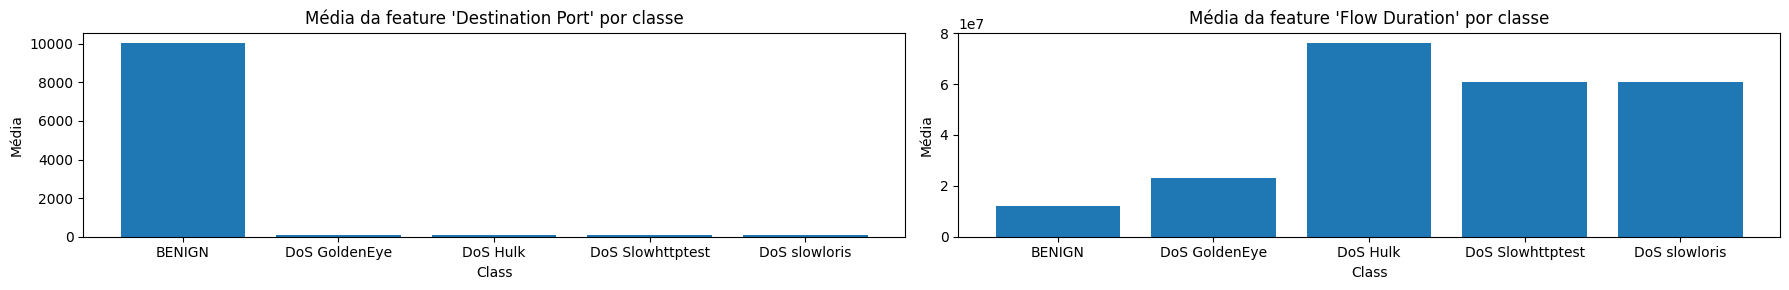

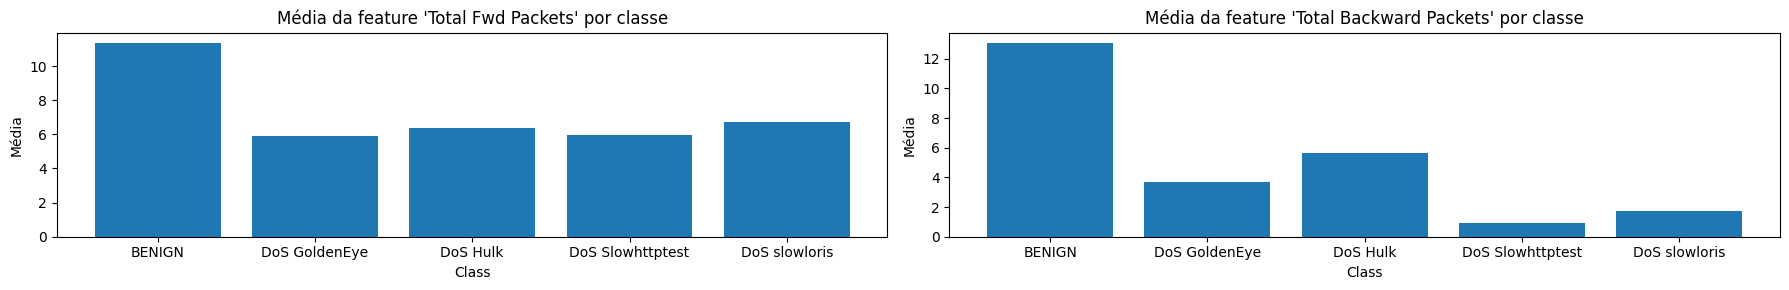

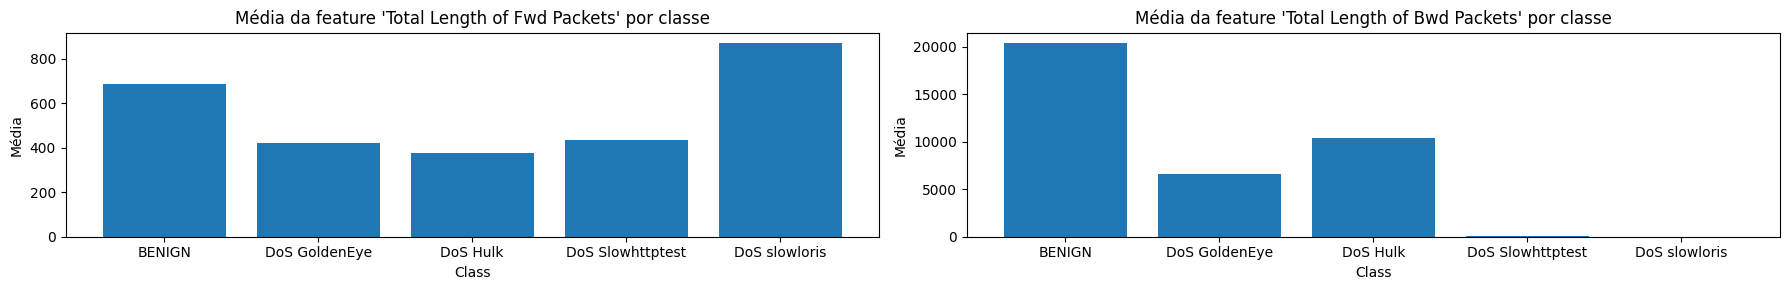

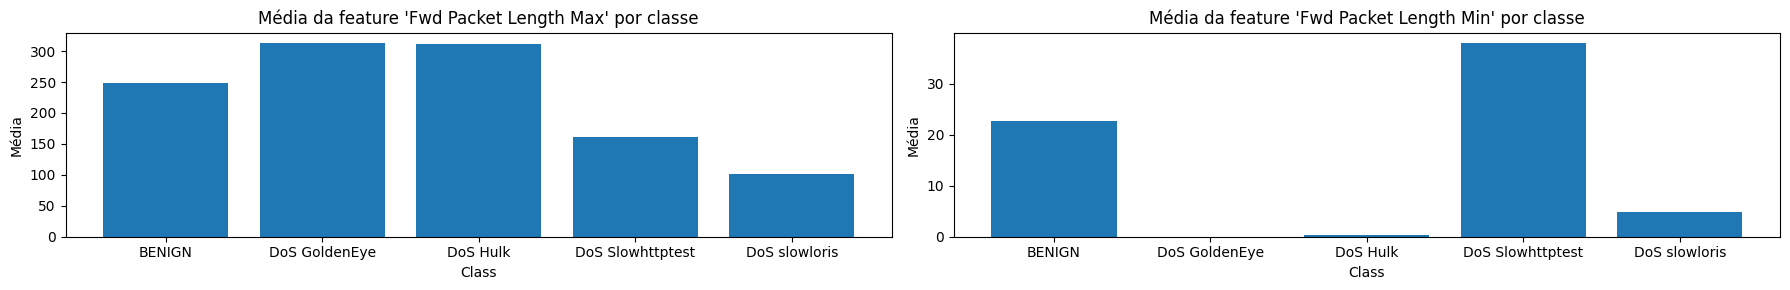

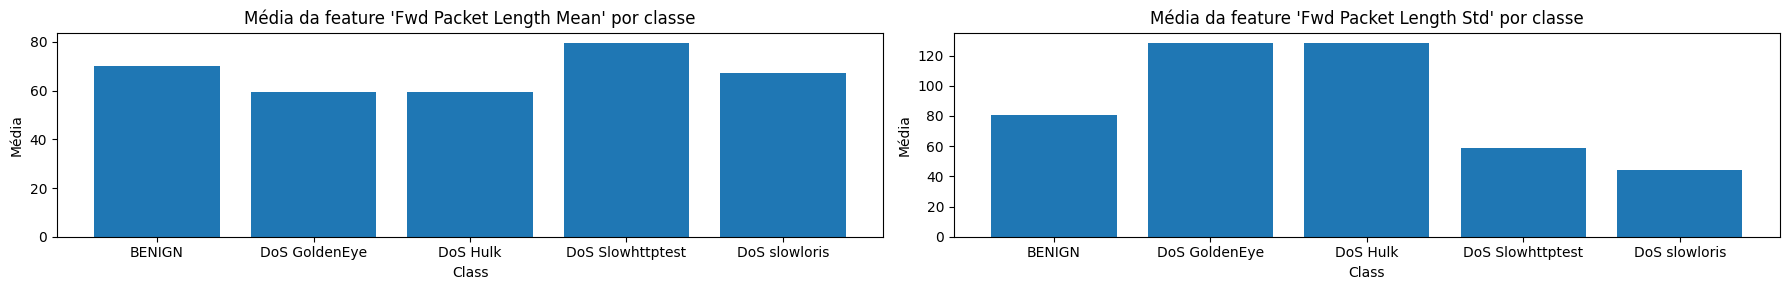

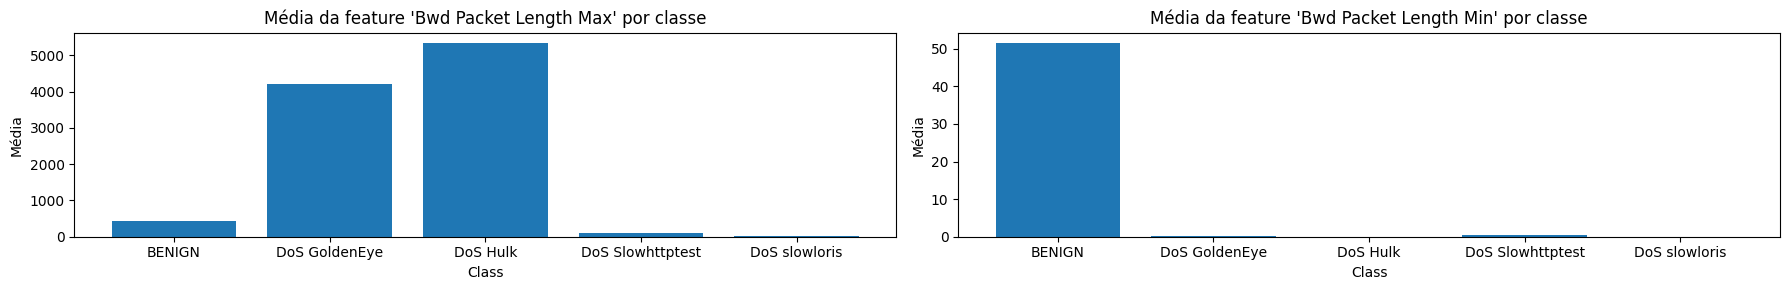

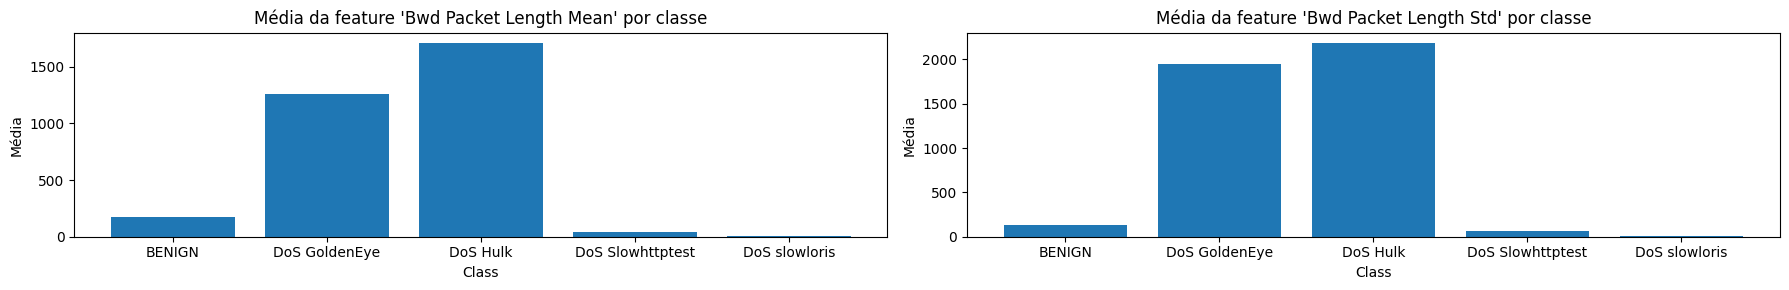

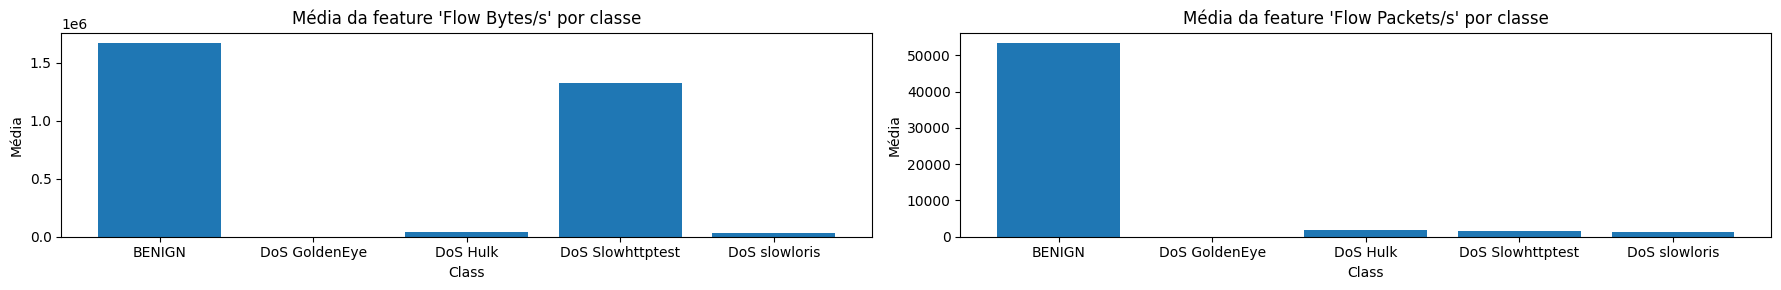

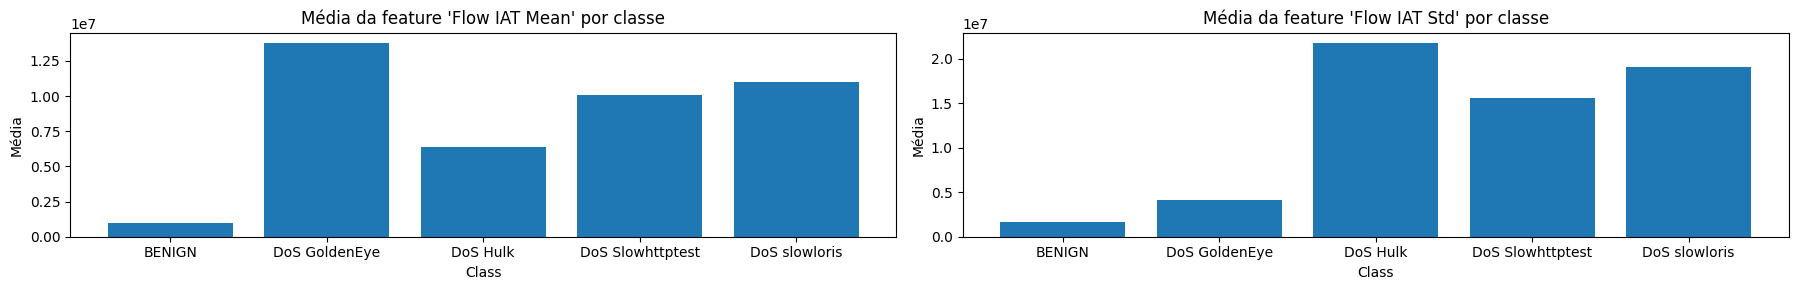

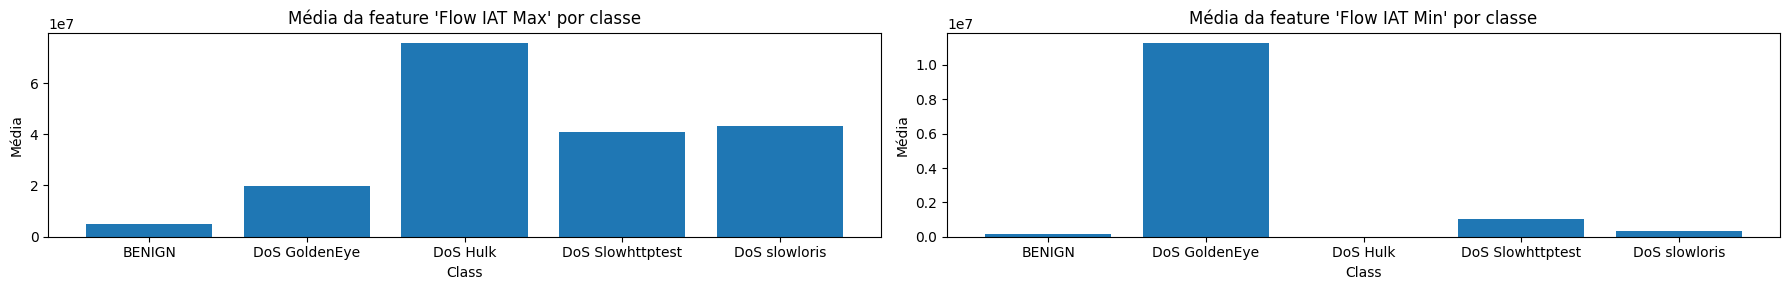

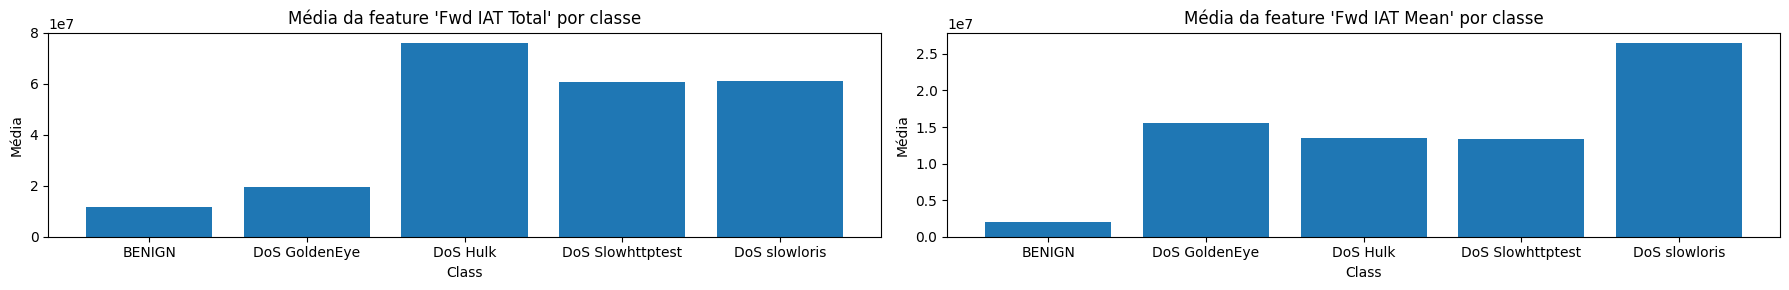

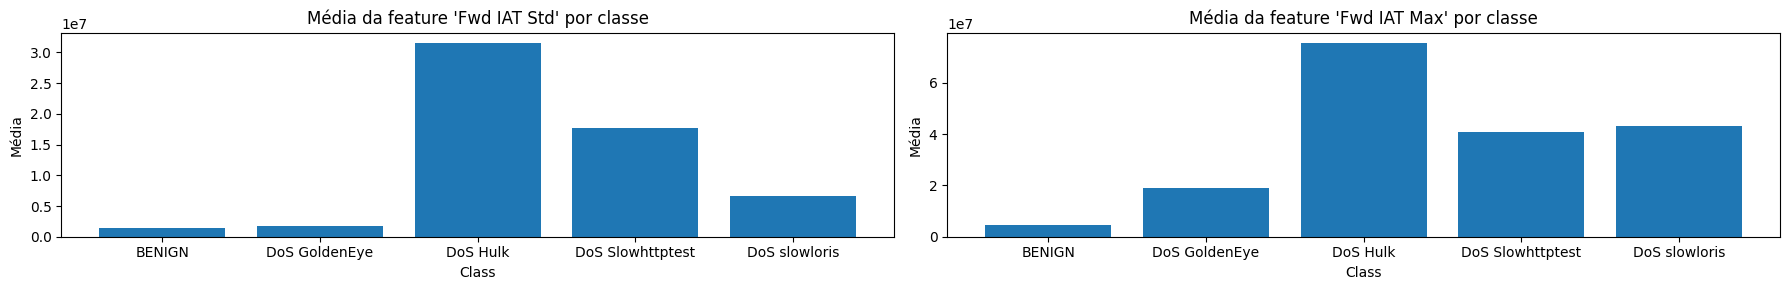

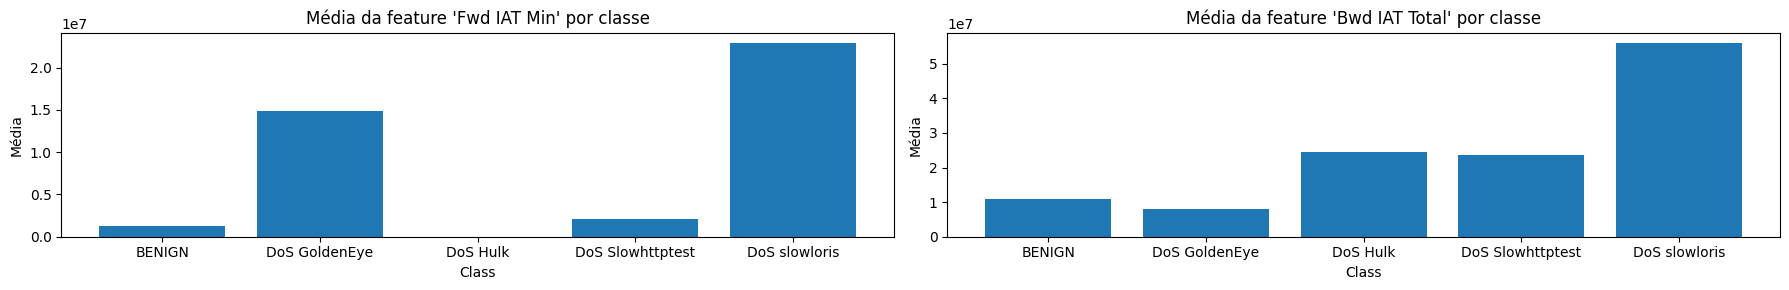

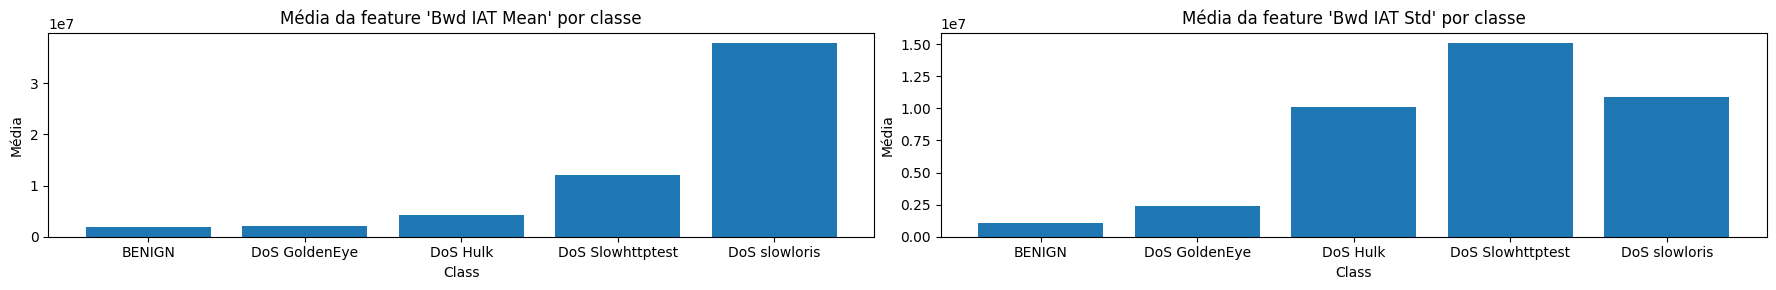

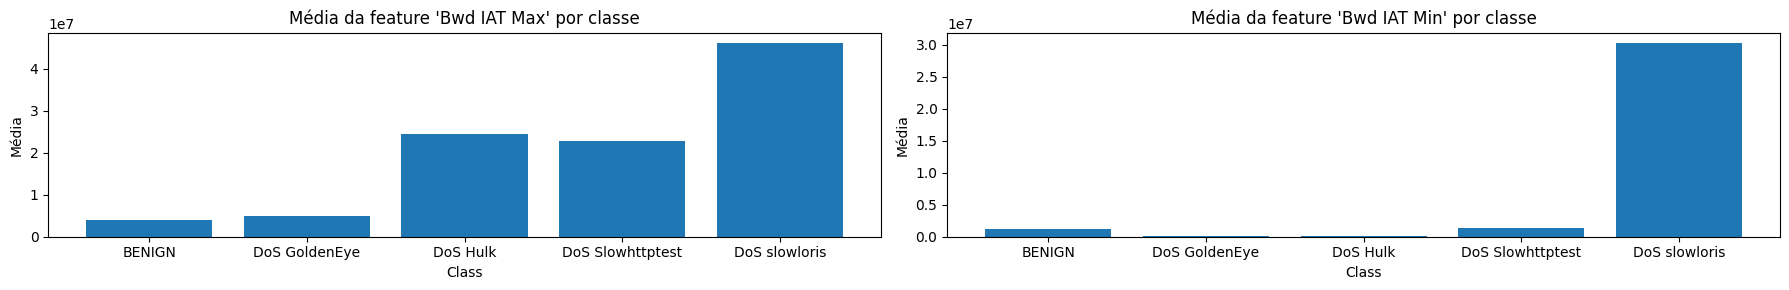

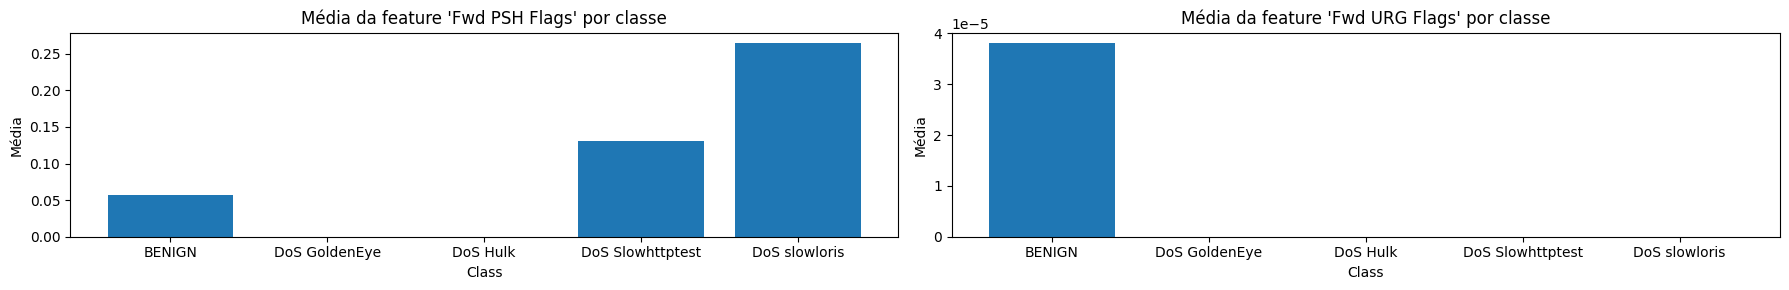

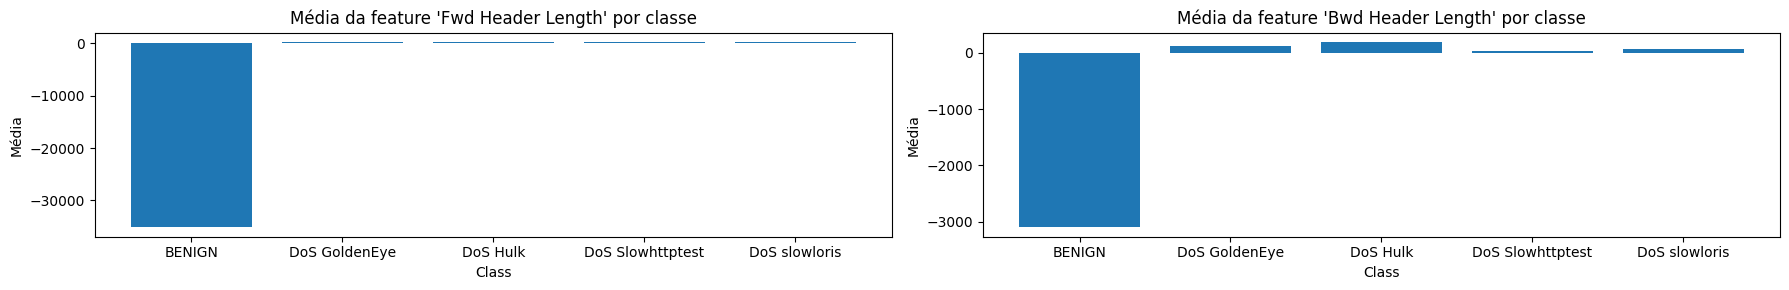

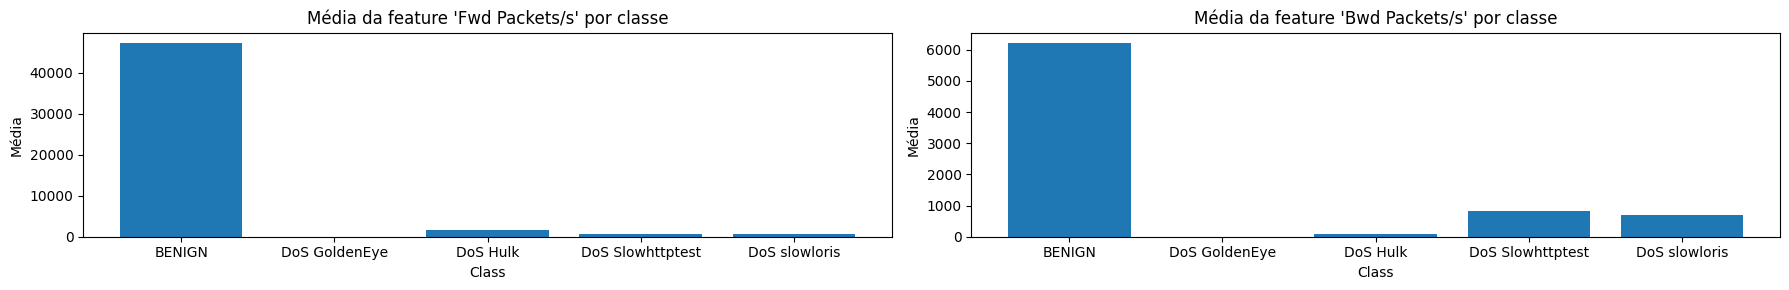

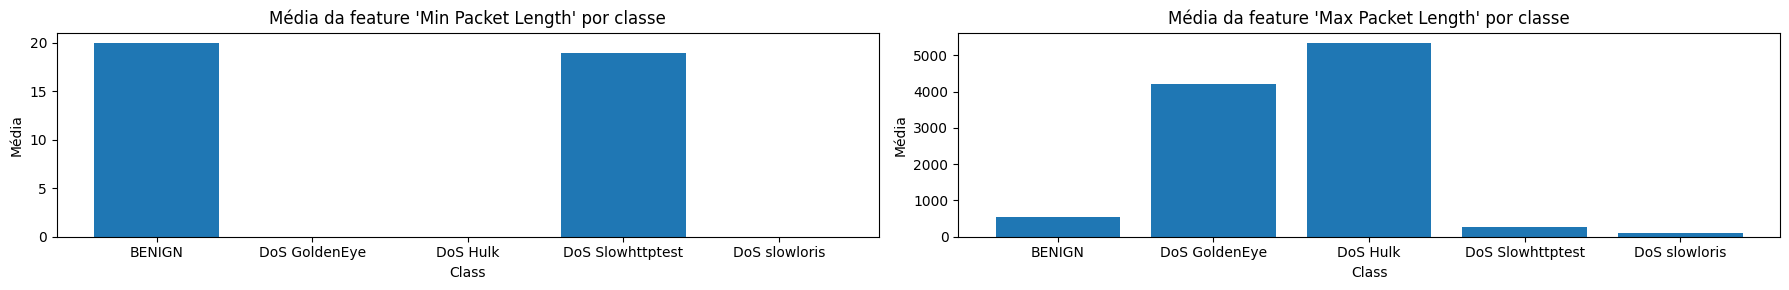

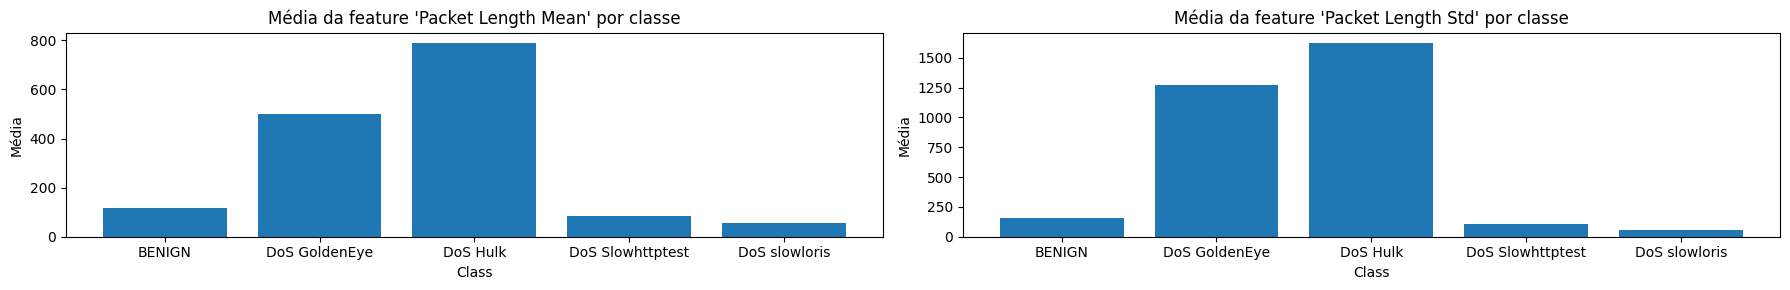

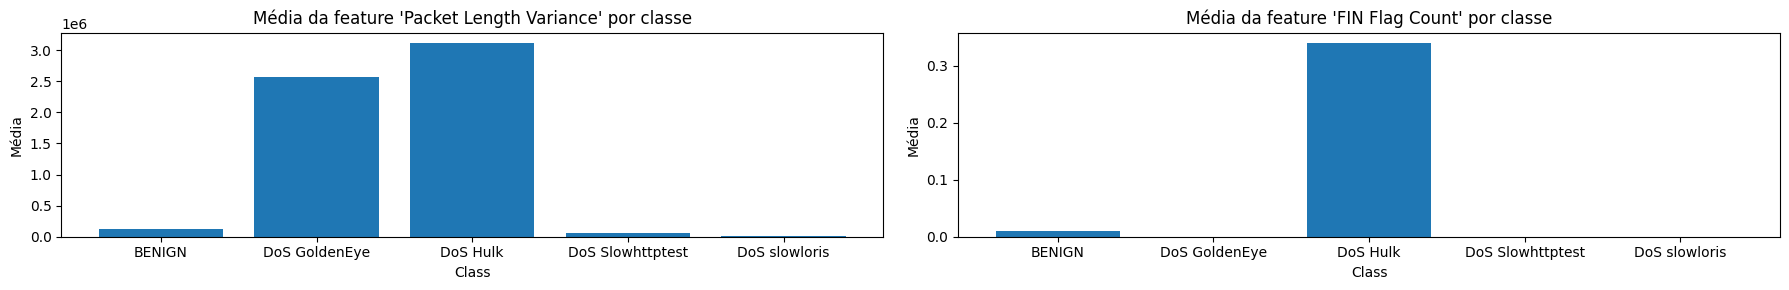

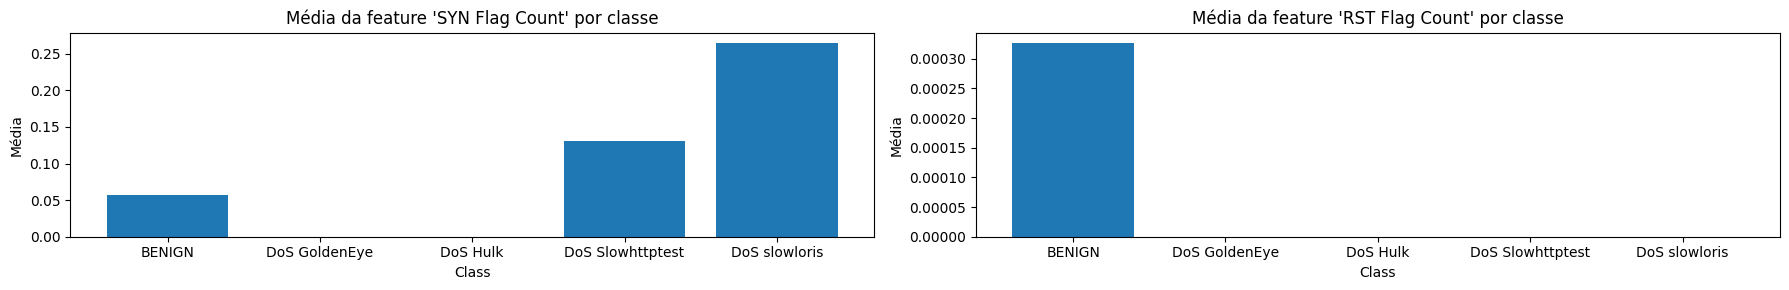

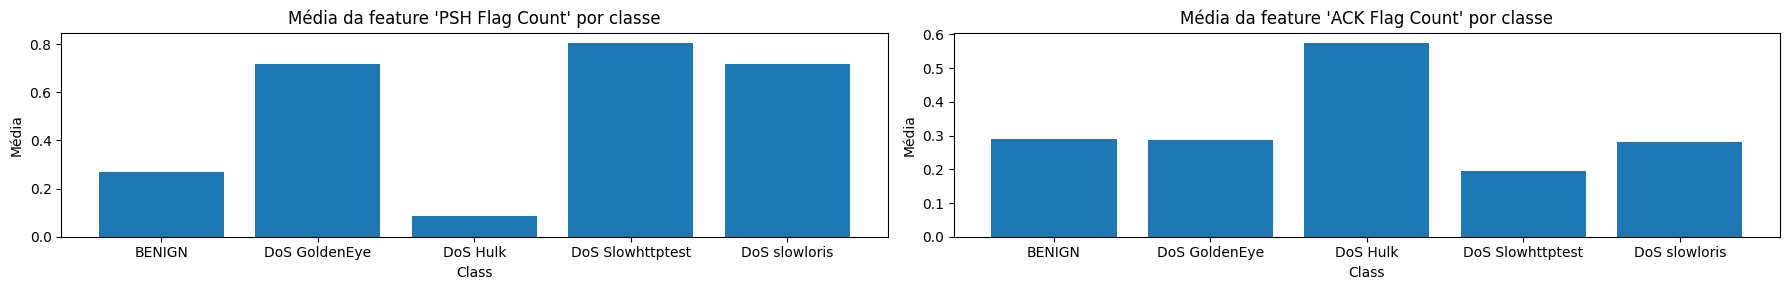

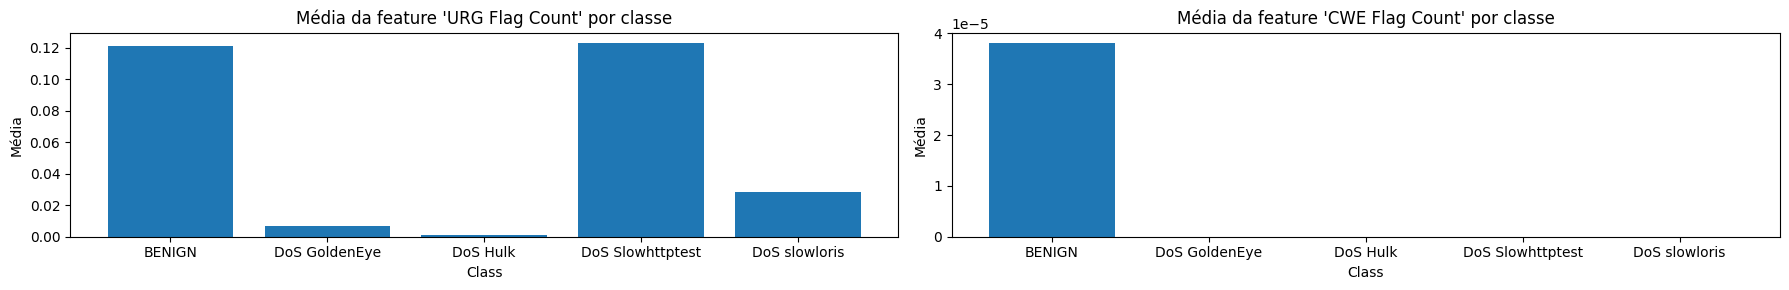

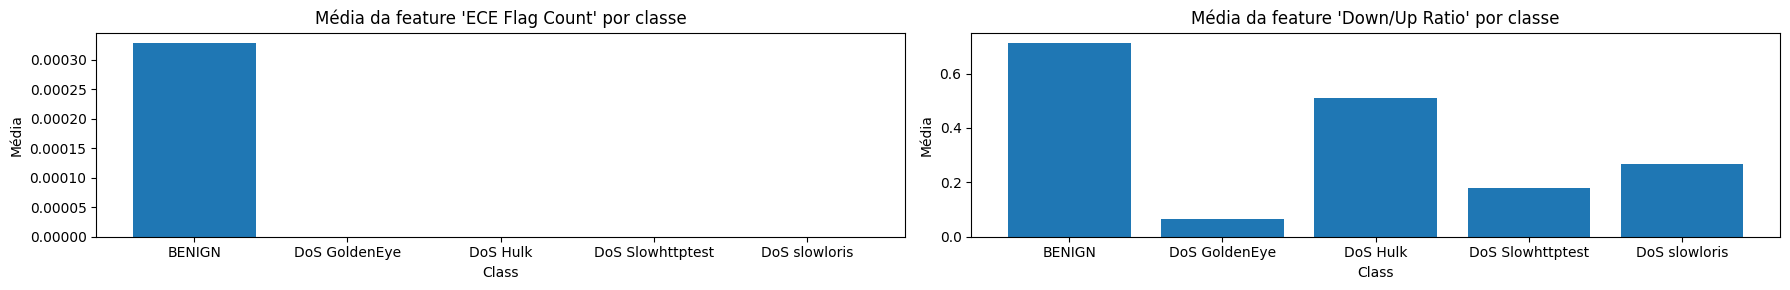

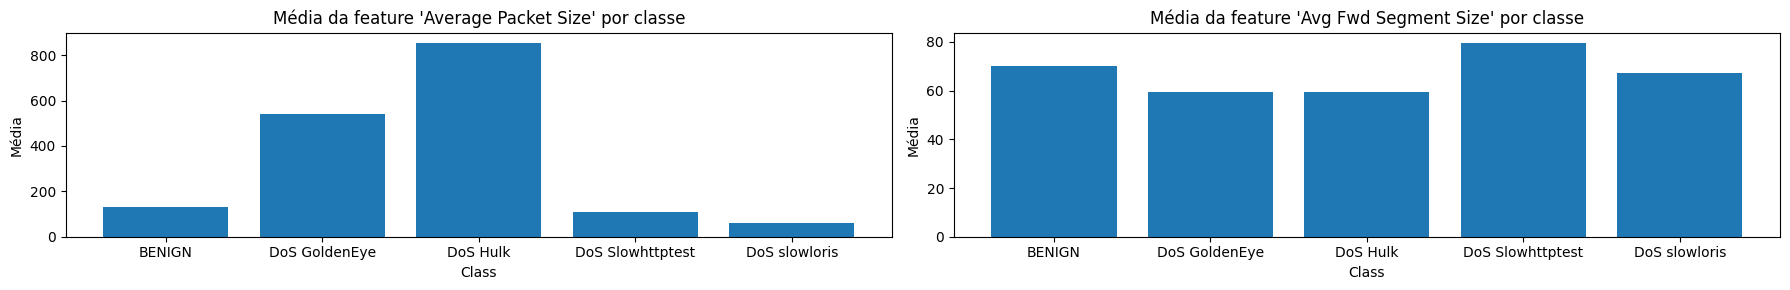

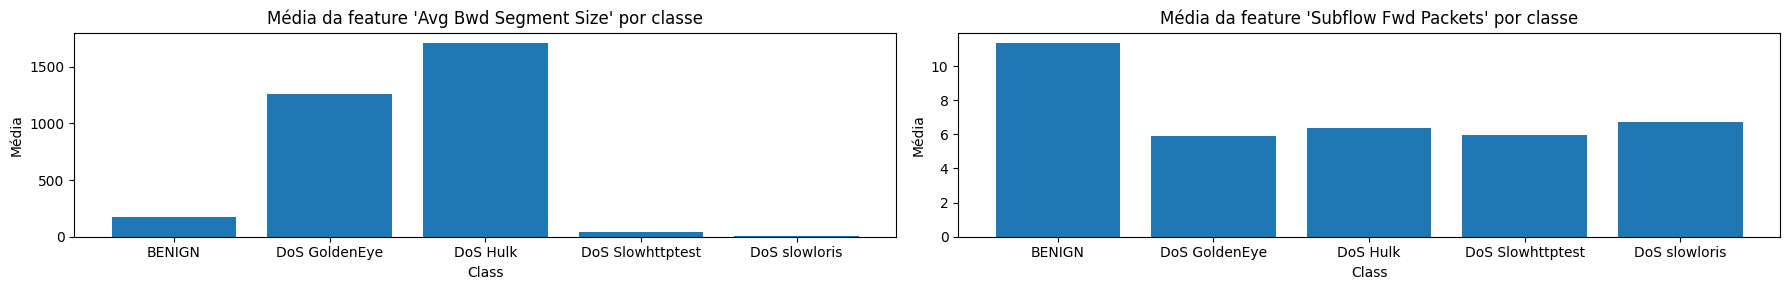

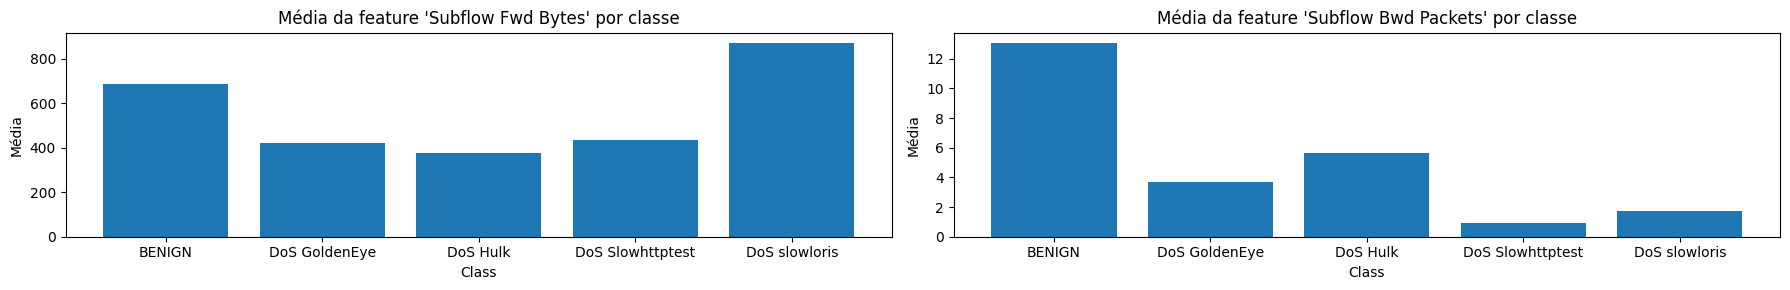

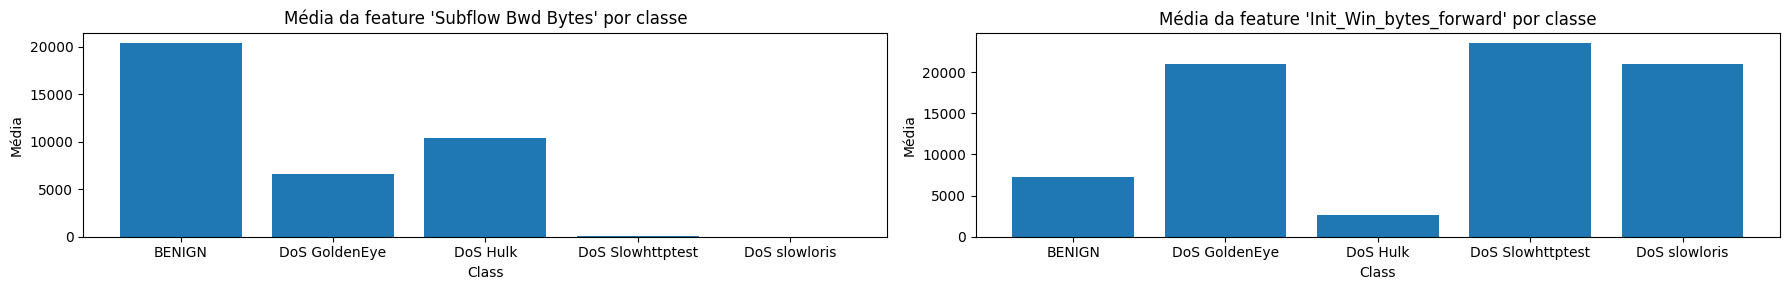

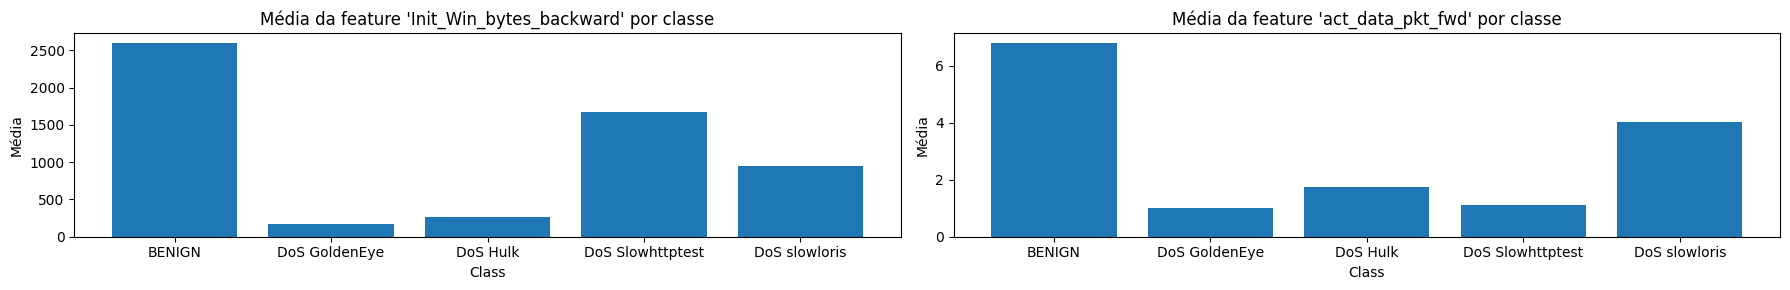

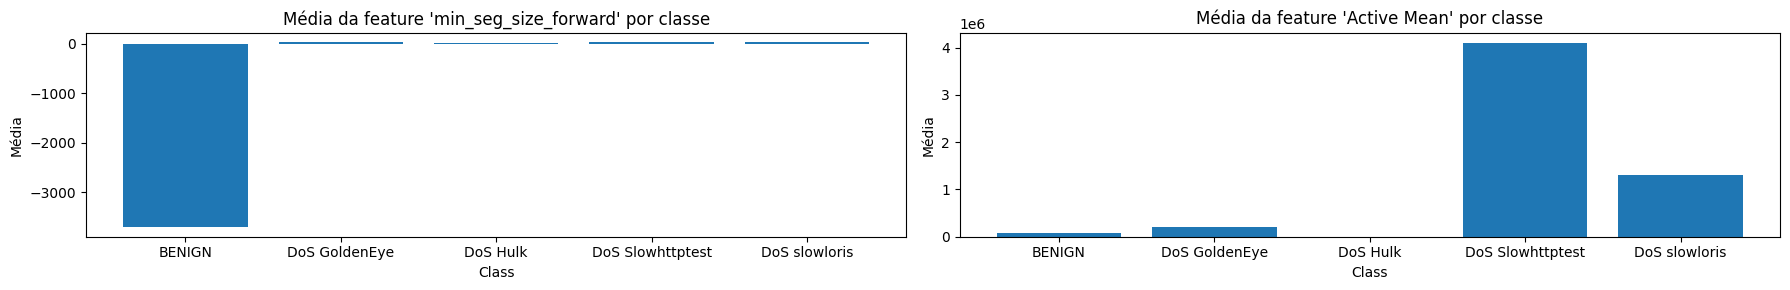

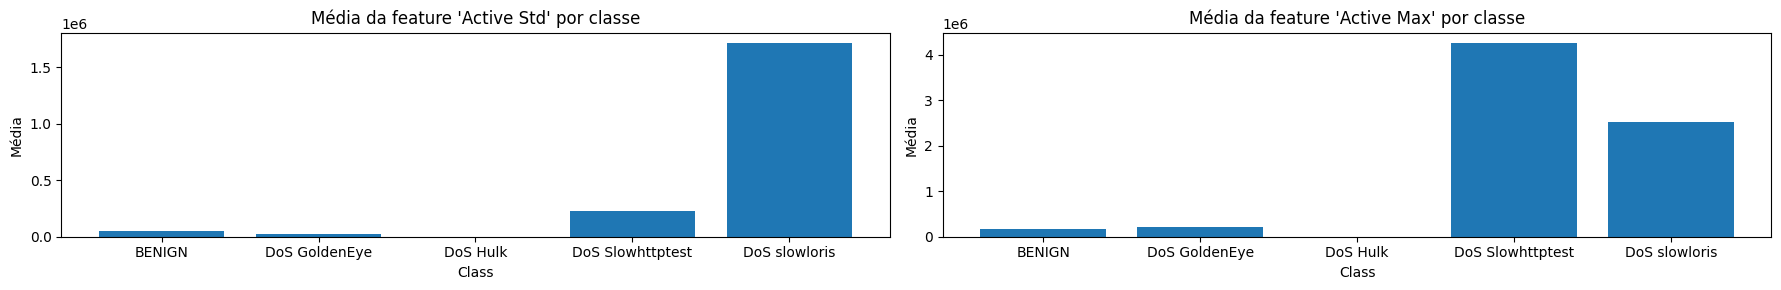

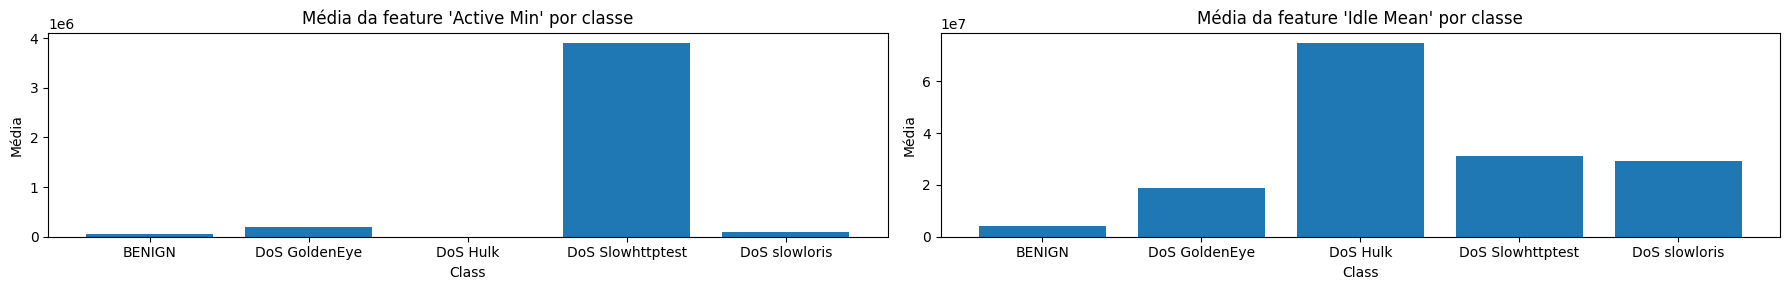

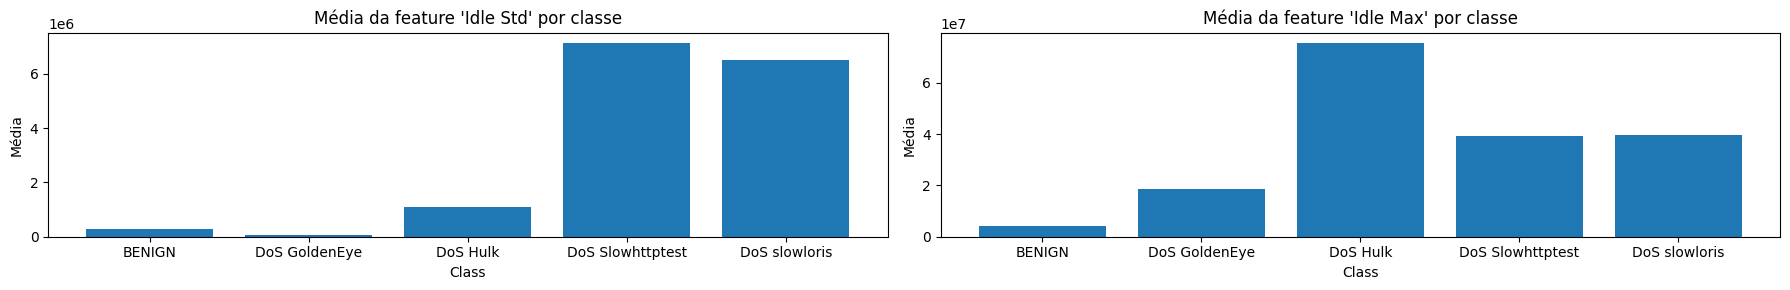

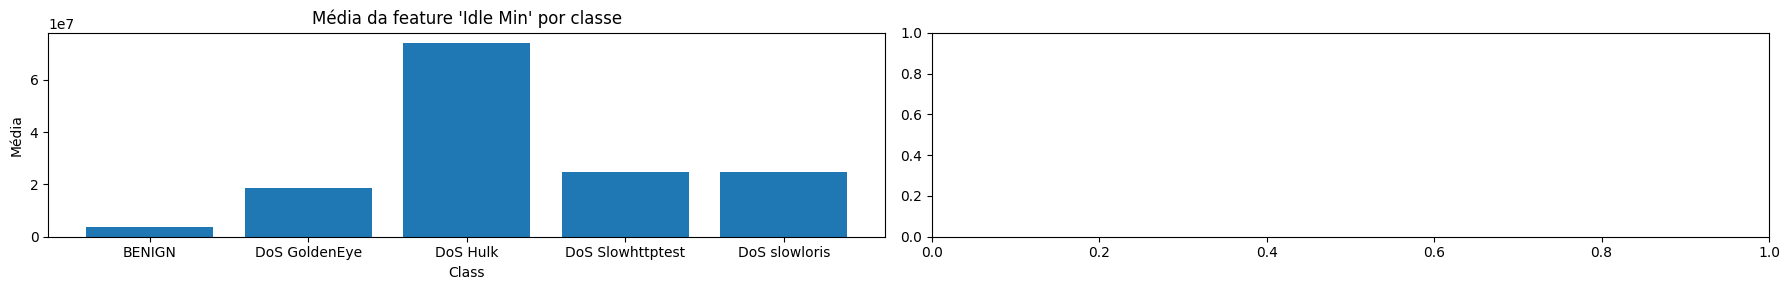

In [7]:
def plot_medias_por_classe(df, class_col="Label"):
    medias = df.groupby(class_col).mean(numeric_only=True)
    cols = medias.columns
    n = len(cols)

    for i in range(0, n, 2):
        fig, axs = plt.subplots(1, 2, figsize=(18, 3))
        for j in range(2):
            if i + j < n:
                axs[j].bar(medias.index.astype(str), medias[cols[i + j]])
                axs[j].set_title(f"Média da feature '{cols[i + j]}' por classe")
                axs[j].set_xlabel("Class")
                axs[j].set_ylabel("Média")
        plt.tight_layout()
        plt.show()

plot_medias_por_classe(df)

In [8]:
# Identificar colunas com valores negativos
cols_numericas = df.select_dtypes(include=[np.number]).columns
mask_negativos = df[cols_numericas] < 0

# Contar valores negativos por coluna
contagem_negativos = mask_negativos.sum()
colunas_com_negativos = contagem_negativos[contagem_negativos > 0]

# Criar tabela de análise
tabela_negativos = pd.DataFrame({
    'Coluna': colunas_com_negativos.index,
    'Valores Negativos': colunas_com_negativos.values,
    'Total de Linhas': len(df),
    'Percentual (%)': (colunas_com_negativos.values / len(df) * 100).round(4)
})

tabela_negativos = tabela_negativos.sort_values('Valores Negativos', ascending=False).reset_index(drop=True)

tabela_negativos

,Coluna,Valores Negativos,Total de Linhas,Percentual (%)
0,Init_Win_bytes_backward,1168942,2288802,51.0722
1,Init_Win_bytes_forward,911005,2288802,39.8027
2,Flow IAT Min,2850,2288802,0.1245
3,Flow Duration,107,2288802,0.0047
4,Flow Packets/s,107,2288802,0.0047
5,Flow IAT Mean,107,2288802,0.0047
6,Flow IAT Max,107,2288802,0.0047
7,Flow Bytes/s,78,2288802,0.0034
8,Fwd Header Length,35,2288802,0.0015
9,min_seg_size_forward,35,2288802,0.0015


# Treino/Teste

In [8]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(df, test_size=0.20, random_state=42, stratify=df['Label'])

In [97]:
# Resumo da divisão treino / teste e distribuição de classes
def resumo_divisao(df_train, df_test, label_col=target):
    summary = []
    for name, df in (('train', df_train), ('test', df_test)):
        n_features = df.shape[1] - (1 if label_col in df.columns else 0)
        summary.append({
            'n_samples': len(df),
            'n_features': n_features,
            'n_classes': df[label_col].nunique(),
            'memory_MB': round(df.memory_usage(deep=True).sum() / 1024**2, 2)
        })
    summary_df = pd.DataFrame(summary, index=['train','test'])
    
    # distribuição por classe
    dist_train = df_train[label_col].value_counts().sort_index()
    dist_test  = df_test[label_col].value_counts().sort_index()
    dist = pd.concat([dist_train, dist_test], axis=1).fillna(0).astype(int)
    dist.columns = ['count_train','count_test']
    dist['pct_train'] = (dist['count_train'] / dist['count_train'].sum() * 100).round(2)
    dist['pct_test']  = (dist['count_test']  / dist['count_test'].sum()  * 100).round(2)
    dist['count_total'] = dist['count_train'] + dist['count_test']
    dist['pct_total'] = (dist['count_total'] / dist['count_total'].sum() * 100).round(2)
    
    print("Resumo geral:\n")
    print(summary_df)
    print("\nDistribuição por classe:\n")
    print(dist.sort_values('count_total', ascending=False))
    
    return summary_df, dist

summary_df, dist = resumo_divisao(df_train, df_test, label_col=target)

Resumo geral:

       n_samples  n_features  n_classes  memory_MB
train    1831041          65          5    1018.43
test      457761          65          5     254.61

Distribuição por classe:

                  count_train  count_test  pct_train  pct_test  count_total  \
Label                                                                         
BENIGN                1676045      419012      91.54     91.54      2095057   
DoS Hulk               138277       34569       7.55      7.55       172846   
DoS GoldenEye            8229        2057       0.45      0.45        10286   
DoS slowloris            4308        1077       0.24      0.24         5385   
DoS Slowhttptest         4182        1046       0.23      0.23         5228   

                  pct_total  
Label                        
BENIGN                91.54  
DoS Hulk               7.55  
DoS GoldenEye          0.45  
DoS slowloris          0.24  
DoS Slowhttptest       0.23  


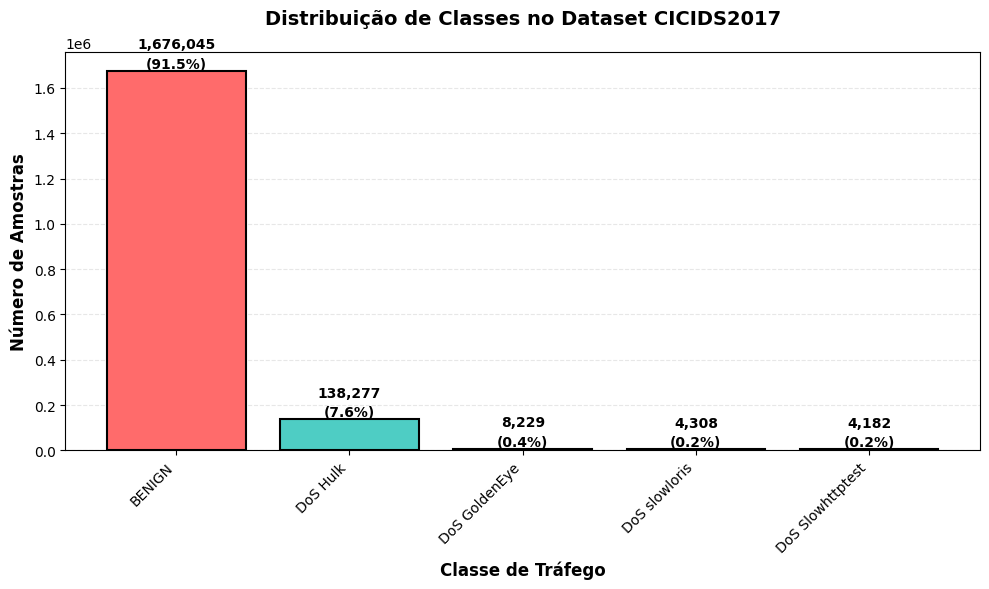

In [96]:
# Criar gráfico de balanceamento de classes
fig, ax = plt.subplots(figsize=(10, 6))

# Dados de contagem por label
label_data = df_train[target].value_counts().sort_values(ascending=False)

# Cores personalizadas
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']

# Gráfico de barras
bars = ax.bar(range(len(label_data)), label_data.values, color=colors, edgecolor='black', linewidth=1.5)

# Personalizações
ax.set_xlabel('Classe de Tráfego', fontsize=12, fontweight='bold')
ax.set_ylabel('Número de Amostras', fontsize=12, fontweight='bold')
ax.set_title('Distribuição de Classes no Dataset CICIDS2017', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(range(len(label_data)))
ax.set_xticklabels(label_data.index, rotation=45, ha='right')

# Adicionar valores nas barras (COM linespacing)
for bar, value in zip(bars, label_data.values):
    height = bar.get_height()
    percentage = (value / label_data.sum()) * 100

    ax.text(
        bar.get_x() + bar.get_width() / 2.,
        height,
        f'{value:,}\n({percentage:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        linespacing=1.5
    )

# Grid
ax.yaxis.grid(True, linestyle='--', alpha=0.3)
ax.set_axisbelow(True)

# Ajustar layout
plt.tight_layout()
plt.savefig('imagens/class_distribution.png', dpi=300)
plt.show()

In [9]:
from imblearn.under_sampling import RandomUnderSampler

def aplicar_undersampling_por_proporcao(
    df,
    target_col="Class",
    proporcao=10,
    classe_referencia=None,
    random_state=42
):
    """
    Aplica undersampling no DataFrame inteiro e retorna apenas o DataFrame balanceado.

    proporcao=10 -> classes majoritárias terão no máximo 10x a quantidade da menor classe
    proporcao=20 -> classes majoritárias terão no máximo 20x a quantidade da menor classe
    """

    class_counts = df[target_col].value_counts()

    if classe_referencia is None:
        menor_qtd = class_counts.min()
    else:
        menor_qtd = class_counts[classe_referencia]

    limite = menor_qtd * proporcao

    sampling_strategy = {
        classe: min(qtd, limite)
        for classe, qtd in class_counts.items()
    }

    rus = RandomUnderSampler(
        sampling_strategy=sampling_strategy,
        random_state=random_state
    )

    df_bal, _ = rus.fit_resample(
        df,
        df[target_col]
    )

    return df_bal

In [11]:
df_train_bal = aplicar_undersampling_por_proporcao(
    df_train,
    target_col="Label",
    proporcao=10
)

df_train_bal["Label"].value_counts()

Label
BENIGN              41820
DoS Hulk            41820
DoS GoldenEye        8229
DoS slowloris        4308
DoS Slowhttptest     4182
Name: count, dtype: int64

In [12]:
# Tabela de balanceamento das classes em df_train_bal
tabela_balanceamento = (
    df_train_bal[target]
    .value_counts()
    .rename_axis('Classe')
    .reset_index(name='Amostras')
)

tabela_balanceamento['Percentual (%)'] = (
    tabela_balanceamento['Amostras'] / tabela_balanceamento['Amostras'].sum() * 100
).round(2)

tabela_balanceamento = tabela_balanceamento.sort_values('Amostras', ascending=False).reset_index(drop=True)

tabela_balanceamento

,Classe,Amostras,Percentual (%)
0,BENIGN,41820,41.67
1,DoS Hulk,41820,41.67
2,DoS GoldenEye,8229,8.20
3,DoS slowloris,4308,4.29
4,DoS Slowhttptest,4182,4.17


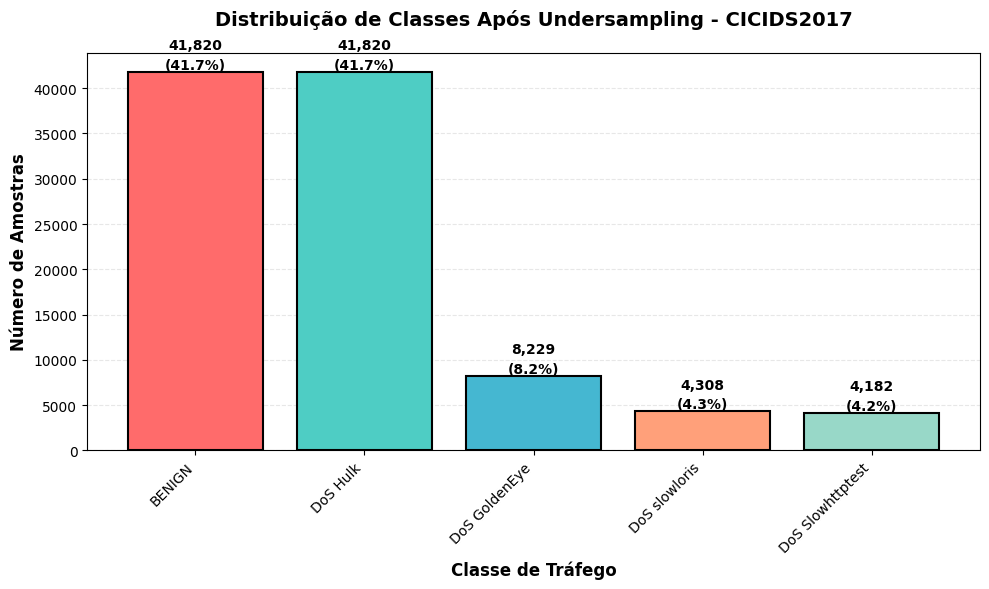

In [13]:
# Criar gráfico de balanceamento de classes APÓS UNDERSAMPLING
fig, ax = plt.subplots(figsize=(10, 6))

# Dados de contagem por label
label_data = df_train_bal[target].value_counts().sort_values(ascending=False)

# Cores personalizadas
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']

# Gráfico de barras
bars = ax.bar(
    range(len(label_data)),
    label_data.values,
    color=colors,
    edgecolor='black',
    linewidth=1.5
)

# Personalizações
ax.set_xlabel('Classe de Tráfego', fontsize=12, fontweight='bold')
ax.set_ylabel('Número de Amostras', fontsize=12, fontweight='bold')
ax.set_title(
    'Distribuição de Classes Após Undersampling - CICIDS2017',
    fontsize=14,
    fontweight='bold',
    pad=20
)

ax.set_xticks(range(len(label_data)))
ax.set_xticklabels(label_data.index, rotation=45, ha='right')

# Adicionar valores nas barras
for bar, value in zip(bars, label_data.values):
    height = bar.get_height()
    percentage = (value / label_data.sum()) * 100

    ax.text(
        bar.get_x() + bar.get_width() / 2.,
        height,
        f'{value:,}\n({percentage:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        linespacing=1.5
    )

# Grid
ax.yaxis.grid(True, linestyle='--', alpha=0.3)
ax.set_axisbelow(True)

# Ajustar layout
plt.tight_layout()

# Salvar imagem
plt.savefig('imagens/class_distribution_undersampling1.png', dpi=300)

# Exibir gráfico
plt.show()